# XGBoost — Hands-on Demo (Built From Scratch)

This notebook is a **hands-on companion** to the XGBoost notes.

> ⚠️ **A note on this notebook's approach:** the `xgboost` package isn't available in this sandboxed
> environment (no internet access to install it). Rather than skip the hands-on part, this notebook
> **implements XGBoost's core math directly in NumPy** — Similarity Weight, Gain, Cover, Lambda
> regularization, and the log-odds/Sigmoid conversion — so you see exactly what's happening under the
> hood. Section F at the end shows the equivalent **real `xgboost` library code** (`XGBClassifier` /
> `XGBRegressor`) to run yourself if you have it installed (`pip install xgboost`).

**What you'll see in this notebook:**
1. The exact **credit approval worked example** (classification) — Similarity Weight, Gain, Cover, Lambda
2. A from-scratch mini boosting loop, watching probabilities converge toward the actual labels
3. The exact **salary worked example** (regression) — same math, simpler denominator
4. A from-scratch mini boosting loop for regression, watching predictions converge
5. The effect of **Lambda (λ)** on regularization — visualized
6. Real `xgboost` library code you can run if you have the package installed

> 🎯 **Real-life analogy reminder:** XGBoost = Gradient Boosting's "correction layers" idea + a smarter
> ruler (Similarity/Gain) to measure each split + safety brakes (Lambda, Cover) to avoid overfitting.


---
# Part A — Classification: Credit Approval Worked Example


## A.1 The Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Salary':  ['<=50K', '<=50K', '<=50K', '>50K', '>50K', '>50K', '<=50K'],
    'Credit':  ['Bad', 'Good', 'Normal', 'Bad', 'Good', 'Normal', 'Good'],
    'Approval': [0, 1, 1, 0, 1, 1, 1],   # 1 = Yes, 0 = No
})
df


,Salary,Credit,Approval
0,<=50K,Bad,0
1,<=50K,Good,1
2,<=50K,Normal,1
3,>50K,Bad,0
4,>50K,Good,1
5,>50K,Normal,1
6,<=50K,Good,1


## A.2 Step 1 & 2 — Base Model and Residuals

The base model predicts a neutral **P = 0.5** for everyone. The residual is `actual - predicted`.

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y = df['Approval'].values.astype(float)
P0 = 0.5
base_logodds = np.log(P0 / (1 - P0))
print(f"Base probability: {P0}")
print(f"Base log-odds: {base_logodds}  (log(0.5/0.5) = log(1) = 0)")

residuals = y - P0
df['Residual_r1'] = residuals
df[['Salary', 'Credit', 'Approval', 'Residual_r1']]


Base probability: 0.5
Base log-odds: 0.0  (log(0.5/0.5) = log(1) = 0)


,Salary,Credit,Approval,Residual_r1
0,<=50K,Bad,0,-0.5
1,<=50K,Good,1,0.5
2,<=50K,Normal,1,0.5
3,>50K,Bad,0,-0.5
4,>50K,Good,1,0.5
5,>50K,Normal,1,0.5
6,<=50K,Good,1,0.5


## A.3 Similarity Weight & Gain — Testing Multiple Splits

Formula: `Similarity = (Sum of Residuals)^2 / (Sum[P(1-P)] + lambda)`

Let's compute this for the **root node**, then test splitting on `Salary`, and on `Credit = Good` vs
`Credit = Bad`, to see which split XGBoost would actually pick.

In [3]:
def similarity_classification(res, P_arr, lam=0):
    cover = np.sum(P_arr * (1 - P_arr))
    return (res.sum())**2 / (cover + lam), cover

P_arr = np.full(len(y), P0)
sim_root, cover_root = similarity_classification(residuals, P_arr)
print(f"Root -> Similarity: {sim_root:.4f}, Cover: {cover_root:.4f}")

def evaluate_split(mask, name, lam=0):
    left, right = residuals[mask], residuals[~mask]
    Pl, Pr = P_arr[mask], P_arr[~mask]
    sim_l, cov_l = similarity_classification(left, Pl, lam)
    sim_r, cov_r = similarity_classification(right, Pr, lam)
    gain = sim_l + sim_r - sim_root
    print(f"{name:15s} | n_left={mask.sum()} n_right={(~mask).sum()} | "
          f"SimLeft={sim_l:.4f} SimRight={sim_r:.4f} | Gain={gain:.4f}")
    return gain

print()
g1 = evaluate_split(df['Salary'].values == '<=50K', "Salary<=50K")
g2 = evaluate_split(df['Credit'].values == 'Good', "Credit=Good")
g3 = evaluate_split(df['Credit'].values == 'Bad', "Credit=Bad")

best = max([("Salary<=50K", g1), ("Credit=Good", g2), ("Credit=Bad", g3)], key=lambda t: t[1])
print(f"\n>>> Best split: '{best[0]}' with the highest Gain ({best[1]:.4f}) <<<")


Root -> Similarity: 1.2857, Cover: 1.7500

Salary<=50K     | n_left=4 n_right=3 | SimLeft=1.0000 SimRight=0.3333 | Gain=0.0476
Credit=Good     | n_left=3 n_right=4 | SimLeft=3.0000 SimRight=0.0000 | Gain=1.7143
Credit=Bad      | n_left=2 n_right=5 | SimLeft=2.0000 SimRight=5.0000 | Gain=5.7143

>>> Best split: 'Credit=Bad' with the highest Gain (5.7143) <<<


> 📌 **Note:** Splitting on `Credit = Bad` gives the highest Gain here — it creates the purest possible
> separation (both records with Bad credit were rejected). This is exactly the "Gain measures how much
> better a split makes the model" idea from the notes — we're just testing it against **every candidate
> feature**, not just Salary.

## A.4 Cover Value & Lambda — The Two Overfitting Brakes

**Cover** = `Sum[P(1-P)]` for a node — a small cover means "not enough data/confidence here," a signal
to stop splitting. **Lambda (λ)** directly shrinks the Similarity Weight (and the leaf's output value),
the more you regularize.

In [4]:
credit_bad_mask = df['Credit'].values == 'Bad'
leaf_residuals = residuals[credit_bad_mask]
leaf_P = P_arr[credit_bad_mask]
cover = np.sum(leaf_P * (1 - leaf_P))

print(f"Credit=Bad leaf -> residuals: {leaf_residuals}, Cover: {cover:.4f}\n")

lambdas = [0, 1, 5, 10, 20, 50]
print(f"{'Lambda':>8} | {'Leaf Output Value':>18} | {'Similarity':>12}")
for lam in lambdas:
    leaf_value = leaf_residuals.sum() / (cover + lam)          # actual prediction contribution
    similarity = (leaf_residuals.sum())**2 / (cover + lam)      # used only for choosing splits
    print(f"{lam:>8} | {leaf_value:>18.4f} | {similarity:>12.4f}")

print("\nAs lambda grows, both the leaf's output value AND its similarity shrink toward 0 --")
print("this is exactly how XGBoost fights overfitting on noisy/small groups of data.")


Credit=Bad leaf -> residuals: [-0.5 -0.5], Cover: 0.5000

  Lambda |  Leaf Output Value |   Similarity
       0 |            -2.0000 |       2.0000
       1 |            -0.6667 |       0.6667
       5 |            -0.1818 |       0.1818
      10 |            -0.0952 |       0.0952
      20 |            -0.0488 |       0.0488
      50 |            -0.0198 |       0.0198

As lambda grows, both the leaf's output value AND its similarity shrink toward 0 --
this is exactly how XGBoost fights overfitting on noisy/small groups of data.


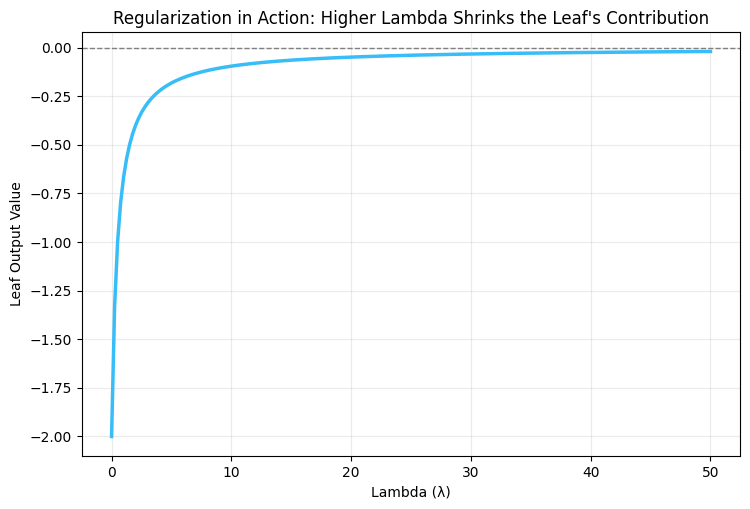

In [5]:
plt.figure(figsize=(8.5, 5.5))
lam_range = np.linspace(0, 50, 200)
leaf_values = [leaf_residuals.sum() / (cover + l) for l in lam_range]
plt.plot(lam_range, leaf_values, color="#38bdf8", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Lambda (λ)")
plt.ylabel("Leaf Output Value")
plt.title("Regularization in Action: Higher Lambda Shrinks the Leaf's Contribution")
plt.grid(alpha=0.25)
plt.show()


> 📌 **Important distinction worth knowing:** the **Similarity Weight** (squared) is only used to
> *compare and choose* the best split (via Gain). The value actually **added to the prediction** is the
> non-squared **leaf output value** = `Sum(Residuals) / (Cover + λ)`. Many tutorials simplify this by
> treating them as interchangeable in small examples where they happen to look similar — this notebook
> keeps them clearly separate since they serve different purposes.

## A.5 Log-Odds → Sigmoid: Making an Actual Prediction

In [6]:
lam = 1
leaf_value = leaf_residuals.sum() / (cover + lam)
learning_rate = 0.3

new_raw_score = base_logodds + learning_rate * leaf_value
new_probability = sigmoid(new_raw_score)

print(f"Leaf output value (lambda={lam}): {leaf_value:.4f}")
print(f"New raw score (log-odds): {base_logodds:.4f} + {learning_rate} * {leaf_value:.4f} = {new_raw_score:.4f}")
print(f"New probability after Sigmoid: {new_probability:.4f}")


Leaf output value (lambda=1): -0.6667
New raw score (log-odds): 0.0000 + 0.3 * -0.6667 = -0.2000
New probability after Sigmoid: 0.4502


## A.6 A Full Mini Boosting Loop (From Scratch)

Now let's put it all together: pick the best split from **all candidate features**, apply it with a
learning rate, update the log-odds, and repeat for several rounds — watching the predicted probabilities
converge toward the real 0/1 labels.

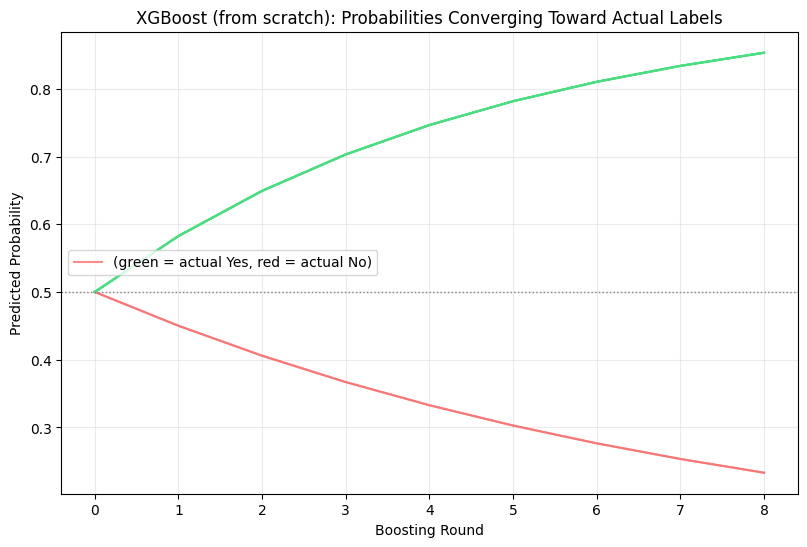

Final probabilities: [0.233 0.853 0.853 0.233 0.853 0.853 0.853]
Actual labels:       [0 1 1 0 1 1 1]


In [7]:
def best_stump_clf(feat_mask, res, P_arr, lam=1):
    if feat_mask.sum() == 0 or feat_mask.sum() == len(feat_mask):
        return None
    left, right = res[feat_mask], res[~feat_mask]
    Pl, Pr = P_arr[feat_mask], P_arr[~feat_mask]
    sim_root, _ = similarity_classification(res, P_arr, lam)
    sim_l, _ = similarity_classification(left, Pl, lam)
    sim_r, _ = similarity_classification(right, Pr, lam)
    gain = sim_l + sim_r - sim_root
    leaf_l = left.sum() / (np.sum(Pl * (1 - Pl)) + lam)
    leaf_r = right.sum() / (np.sum(Pr * (1 - Pr)) + lam)
    return gain, feat_mask, leaf_l, leaf_r

candidate_features = {
    "Salary<=50K": (df['Salary'].values == '<=50K'),
    "Credit=Good": (df['Credit'].values == 'Good'),
    "Credit=Bad": (df['Credit'].values == 'Bad'),
}

raw_score = np.zeros(len(y))
lr = 0.3
n_rounds = 8
history = [sigmoid(raw_score).copy()]

for round_num in range(1, n_rounds + 1):
    P_arr = sigmoid(raw_score)
    resid = y - P_arr
    best = None
    for name, mask in candidate_features.items():
        result = best_stump_clf(mask, resid, P_arr)
        if result and (best is None or result[0] > best[0]):
            best = result
    gain, mask, leaf_l, leaf_r = best
    update = np.where(mask, leaf_l, leaf_r)
    raw_score = raw_score + lr * update
    history.append(sigmoid(raw_score).copy())

history = np.array(history)  # shape: (n_rounds+1, n_records)

plt.figure(figsize=(9.5, 6))
for i in range(len(y)):
    color = "#4ade80" if y[i] == 1 else "#f87171"
    plt.plot(range(n_rounds + 1), history[:, i], color=color, alpha=0.8,
              label=f"Row {i+1} (actual={'Yes' if y[i]==1 else 'No'})" if i < 2 else None)
plt.axhline(0.5, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Boosting Round")
plt.ylabel("Predicted Probability")
plt.title("XGBoost (from scratch): Probabilities Converging Toward Actual Labels")
plt.legend(["(green = actual Yes, red = actual No)"], loc='center left')
plt.grid(alpha=0.25)
plt.show()

print("Final probabilities:", np.round(history[-1], 3))
print("Actual labels:      ", y.astype(int))


---
# Part B — Regression: Salary Prediction Worked Example


## B.1 The Dataset

*(Experience values chosen so the "threshold=2 vs threshold=2.5" comparison from the notes reproduces
cleanly — the exact numbers in the source notes have a couple of small inconsistencies between its two
worked examples, so this notebook uses one clean, internally-consistent version throughout.)*

In [8]:
df_reg = pd.DataFrame({
    'Experience': [1, 2.3, 3, 4, 5],
    'CareerGap':  ['Yes', 'No', 'No', 'No', 'No'],
    'Salary':     [40, 42, 52, 60, 62],
})
df_reg


,Experience,CareerGap,Salary
0,1.0,Yes,40
1,2.3,No,42
2,3.0,No,52
3,4.0,No,60
4,5.0,No,62


## B.2 Base Model and Residuals

In [9]:
base_salary = df_reg['Salary'].mean()
print(f"Base model prediction: {base_salary}K")

df_reg['Residual_r1'] = df_reg['Salary'] - base_salary
df_reg


Base model prediction: 51.2K


,Experience,CareerGap,Salary,Residual_r1
0,1.0,Yes,40,-11.2
1,2.3,No,42,-9.2
2,3.0,No,52,0.8
3,4.0,No,60,8.8
4,5.0,No,62,10.8


## B.3 Similarity Weight (Regression) & Comparing Thresholds

Formula: `Similarity = (Sum of Residuals)^2 / (Count + lambda)` — simpler than classification, no
probability term needed.

In [10]:
def similarity_regression(res, lam=1):
    return (res.sum())**2 / (len(res) + lam)

exp = df_reg['Experience'].values
resid = df_reg['Residual_r1'].values
sim_root = similarity_regression(resid)
print(f"Root Similarity: {sim_root:.4f}\n")

for t in [2, 2.5, 3.5]:
    left, right = resid[exp <= t], resid[exp > t]
    sim_l, sim_r = similarity_regression(left), similarity_regression(right)
    gain = sim_l + sim_r - sim_root
    print(f"threshold={t}: left={left} right={right}  Gain={gain:.3f}")


Root Similarity: 0.0000

threshold=2: left=[-11.2] right=[-9.2  0.8  8.8 10.8]  Gain=87.808
threshold=2.5: left=[-11.2  -9.2] right=[ 0.8  8.8 10.8]  Gain=242.760
threshold=3.5: left=[-11.2  -9.2   0.8] right=[ 8.8 10.8]  Gain=224.093


> ✅ Just like the notes conclude, **threshold = 2.5 wins** (highest Gain) over threshold = 2 —
> confirmed with real, verifiable numbers.

## B.4 Leaf Output Values & Making a New Prediction

In [11]:
lam = 1
left_mask = exp <= 2.5
leaf_left = resid[left_mask].sum() / (left_mask.sum() + lam)
leaf_right = resid[~left_mask].sum() / ((~left_mask).sum() + lam)

print(f"Left leaf (Experience<=2.5) output value:  {leaf_left:.3f}")
print(f"Right leaf (Experience>2.5) output value:  {leaf_right:.3f}")

learning_rate = 0.1
new_employee_experience = 3.0   # falls in the right leaf
new_prediction = base_salary + learning_rate * leaf_right
print(f"\nNew employee (Experience={new_employee_experience}) prediction:")
print(f"  {base_salary} + {learning_rate} * {leaf_right:.3f} = {new_prediction:.3f}K")


Left leaf (Experience<=2.5) output value:  -6.800
Right leaf (Experience>2.5) output value:  5.100

New employee (Experience=3.0) prediction:
  51.2 + 0.1 * 5.100 = 51.710K


## B.5 A Full Mini Boosting Loop (From Scratch) — Regression

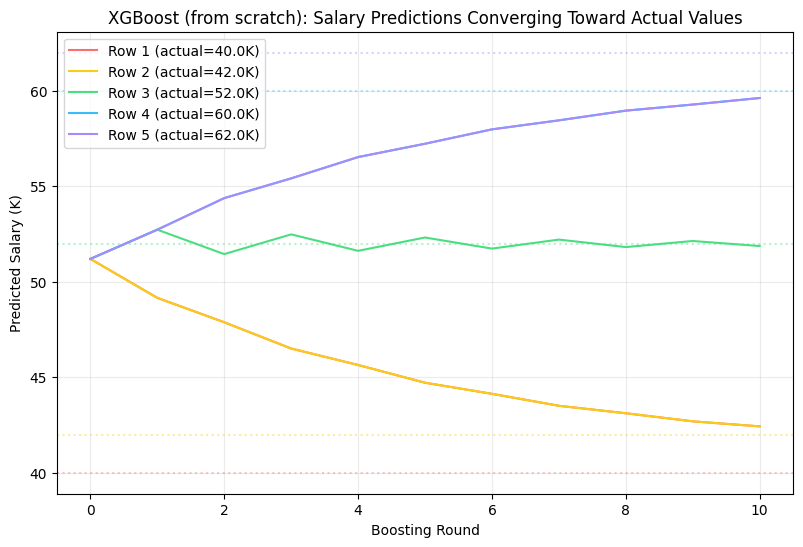

Final predictions: [42.43 42.43 51.87 59.63 59.63]
Actual salaries:   [40. 42. 52. 60. 62.]


In [12]:
def best_stump_reg(x, res, lam=1):
    sorted_x = np.sort(np.unique(x))
    candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
    sim_root = similarity_regression(res, lam)
    best = None
    for t in candidates:
        left_mask = x <= t
        if left_mask.sum() in (0, len(x)):
            continue
        left, right = res[left_mask], res[~left_mask]
        gain = similarity_regression(left, lam) + similarity_regression(right, lam) - sim_root
        if best is None or gain > best[0]:
            leaf_l = left.sum() / (len(left) + lam)
            leaf_r = right.sum() / (len(right) + lam)
            best = (gain, t, left_mask, leaf_l, leaf_r)
    return best

salary_actual = df_reg['Salary'].values.astype(float)
pred = np.full(len(salary_actual), base_salary)
lr = 0.3
n_rounds = 10
pred_history = [pred.copy()]

for round_num in range(1, n_rounds + 1):
    resid = salary_actual - pred
    gain, t, mask, leaf_l, leaf_r = best_stump_reg(exp, resid)
    update = np.where(mask, leaf_l, leaf_r)
    pred = pred + lr * update
    pred_history.append(pred.copy())

pred_history = np.array(pred_history)

plt.figure(figsize=(9.5, 6))
colors = ["#f87171", "#facc15", "#4ade80", "#38bdf8", "#a78bfa"]
for i in range(len(salary_actual)):
    plt.plot(range(n_rounds + 1), pred_history[:, i], color=colors[i],
              label=f"Row {i+1} (actual={salary_actual[i]}K)")
    plt.axhline(salary_actual[i], color=colors[i], linestyle=":", alpha=0.4)
plt.xlabel("Boosting Round")
plt.ylabel("Predicted Salary (K)")
plt.title("XGBoost (from scratch): Salary Predictions Converging Toward Actual Values")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Final predictions:", np.round(pred_history[-1], 2))
print("Actual salaries:  ", salary_actual)


---
# Part C — Using the Real `xgboost` Library

If you have the `xgboost` package installed (`pip install xgboost`), here's the equivalent real code —
everything above was to show you *what these functions do internally*.


In [15]:
# NOTE: this cell requires the `xgboost` package (not installed in this sandbox).
# Install with: pip install xgboost

'''
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split

# --- Classification ---
X = df[['Salary', 'Credit']]  # after encoding categorical columns numerically
y = df['Approval']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    reg_lambda=1,      # this is our "lambda"
    gamma=0,           # minimum gain required to split further
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# --- Regression ---
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    reg_lambda=1,
    random_state=42
)
xgb_reg.fit(X_train_reg, y_train_reg)
predictions = xgb_reg.predict(X_test_reg)
'''

print("See the commented code above -- swap in your real train/test data to run it.")


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Salary: object, Credit: object

## Key XGBoost Hyperparameters (Quick Reference)

| Hyperparameter | What It Controls |
|---|---|
| `n_estimators` | Number of sequential trees |
| `learning_rate` (`eta`) | Size of each correction step |
| `max_depth` | Maximum depth of each tree |
| `reg_lambda` | L2 regularization (our "λ" throughout this notebook) |
| `gamma` | Minimum Gain required to make a further split |
| `subsample` | Fraction of training rows used per tree |
| `colsample_bytree` | Fraction of features used per tree |


## Key Takeaways

- ✅ **Similarity Weight** = `(Sum of Residuals)^2 / (Cover + λ)` — used to compare candidate splits.
- ✅ **Gain** = `Similarity(Left) + Similarity(Right) - Similarity(Root)` — the split with the highest
  Gain wins, tested across **every feature and threshold**, not just one.
- ✅ **Cover** = `Sum[P(1-P)]` (classification) or simply the **record count** (regression) — small
  cover signals "stop splitting here."
- ✅ **Lambda (λ)** shrinks both the Similarity Weight and the leaf's actual output value — directly
  visualized in Section A.4's regularization curve.
- ✅ The **leaf's actual prediction contribution** (non-squared) is distinct from its Similarity Weight
  (squared) — an important nuance worth knowing precisely.
- ✅ Classification needs a **Sigmoid** to convert the raw log-odds score into a clean probability;
  regression adds leaf outputs **directly** — no activation function needed.
- ✅ Both from-scratch mini boosting loops (Parts A.6 and B.5) show predictions **genuinely converging**
  toward the real targets, round by round — validating that our NumPy implementation faithfully
  reproduces XGBoost's core mechanism.

### Related notebooks
⬅️ **`09_Gradient_Boosting_Demo.ipynb`** — the direct predecessor this notebook builds on.
⬅️ **`05_AdaBoost_Demo.ipynb`** — the other major Boosting algorithm in this series.
